In [1]:
import shap
import lightgbm as lgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import joblib
import numpy as np
import re
from IPython.display import display, HTML

from scipy.stats import mode

In [2]:
predictions = pd.read_parquet('predictions.parquet', engine='pyarrow')
predictions.head()

,id,clean_text,text,party,sentiment
0,1844361929781113331,many failure bidens administration directly tr...,@a_newsman Many failures of Bidens administrat...,democrat,negative
1,1844361929550332320,lie biden told american misinformation set exa...,@atensnut The lies Biden told Americans about ...,democrat,negative
2,1844361928925384711,someone talented fundraising team,@TheDemocrats here’s someone very talented for...,democrat,positive
3,1844361928585654516,chipper usd card working expressionless face,@LifeOfNapaul Chipper USD card isn’t working 😑,democrat,negative
4,1844361927495123076,yes n't done live interview real journalist si...,@MTGrepp Yes. She hasn't done a live interview...,democrat,positive


In [3]:
train = pd.read_parquet('train_labelled.parquet', engine='pyarrow')
train.head()

,clean_text,party,sentiment,sentiment_score
0,maga maha trumpvance2024 trump2024 magamovemen...,republican,positive,0.8479
1,favorite post kamala harris pretending like de...,democrat,positive,0.8545
2,ron desantis signed sb304 price gouging back a...,democrat,positive,0.8979
3,200 people dead hurricane 99 republican voted ...,republican,negative,-0.8662
4,wtaf coward afraid 60 minute 're incapable tel...,republican,negative,-0.9712


## Party Classifier

In [4]:
X_train, y_train = train['clean_text'], train['party']
X_test, y_test = predictions['clean_text'], predictions['party']

SAMPLE_SIZE = min(50000, len(X_test)/100)
print(SAMPLE_SIZE)
TOTAL_RECORDS = len(X_test)
print(TOTAL_RECORDS)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS
print(test_ratio)

if test_ratio < 1.0:
    _, sample_indices, _, _ = train_test_split(
        y_test.index,+
        y_test,
        test_size=test_ratio,
        stratify=y_test,
        random_state=42
    )

    X_sample_test = X_test.loc[sample_indices]
    y_sample_test = y_test.loc[sample_indices]
else:
    X_sample_test = X_test
    y_sample_test = y_test

50000
36029216
0.0013877626424066514


In [5]:
print(len(X_sample_test))
print(len(y_sample_test))

50000
50000


In [6]:
party_model = joblib.load("models/LightGBM_party_classifier.joblib")
tfidf = party_model.named_steps["tfidf"]
lgb_model = party_model.named_steps["clf"]

X_sample_test_tfidf = tfidf.transform(X_sample_test)

In [7]:
print("TF-IDF shape:", X_sample_test_tfidf.shape)
print("Number of features:", len(tfidf.get_feature_names_out()))

TF-IDF shape: (50000, 20000)
Number of features: 20000


In [8]:
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer(X_sample_test_tfidf)

In [9]:
print(type(shap_values.values), shap_values.values.shape)


<class 'scipy.sparse._csr.csr_matrix'> (50000, 20000)


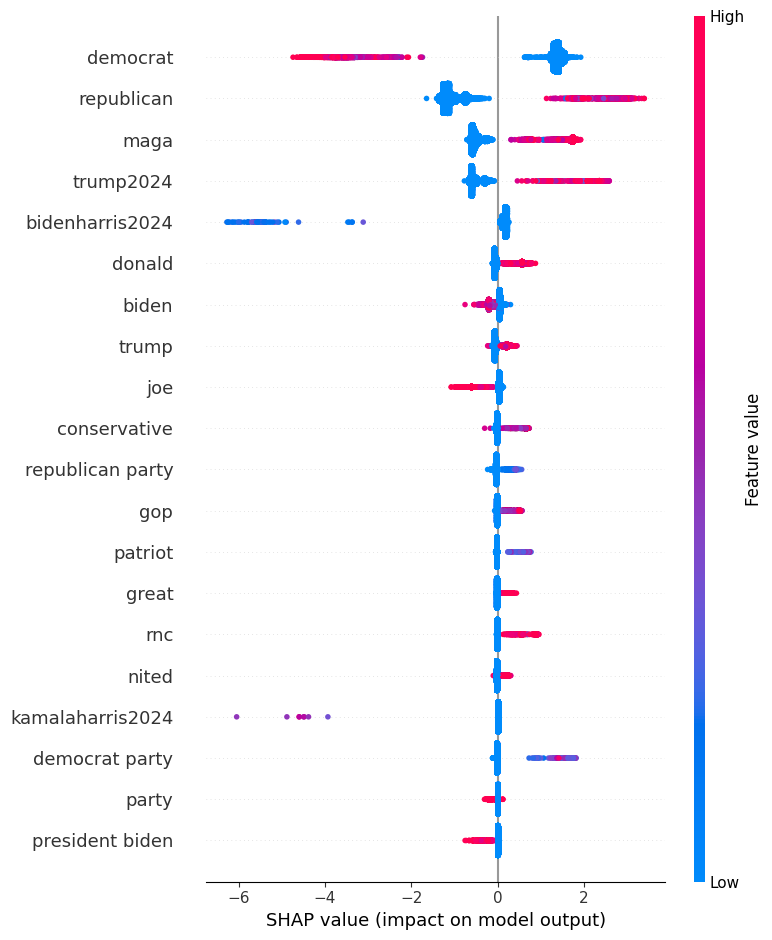

In [10]:
feature_names = tfidf.get_feature_names_out()

shap_dense = shap_values.values.toarray()  # shape: (10000, 20000)
X_dense = X_sample_test_tfidf.toarray()

shap.initjs()

shap.summary_plot(shap_dense, features=X_dense, feature_names=feature_names)


In [11]:
max_abs_shap = np.abs(shap_dense).max(axis=1) 

df_pred = pd.DataFrame({
    'predicted_party': y_sample_test.values,
    'max_abs_shap': max_abs_shap
})

dem_pred = df_pred[df_pred.predicted_party == 'democrat']
rep_pred = df_pred[df_pred.predicted_party == 'republican']

print("Democrat predictions SHAP stats:")
dem_pred['max_abs_shap'].describe()



Democrat predictions SHAP stats:


count    36713.000000
mean         1.485615
std          0.564621
min          1.093019
25%          1.328257
50%          1.357127
75%          1.388829
max          6.272505
Name: max_abs_shap, dtype: float64

In [12]:
print("\nRepublican predictions SHAP stats:")
rep_pred['max_abs_shap'].describe()


Republican predictions SHAP stats:


count    13287.000000
mean         1.696770
std          0.369959
min          1.226042
25%          1.487623
50%          1.545003
75%          1.744525
max          4.024347
Name: max_abs_shap, dtype: float64

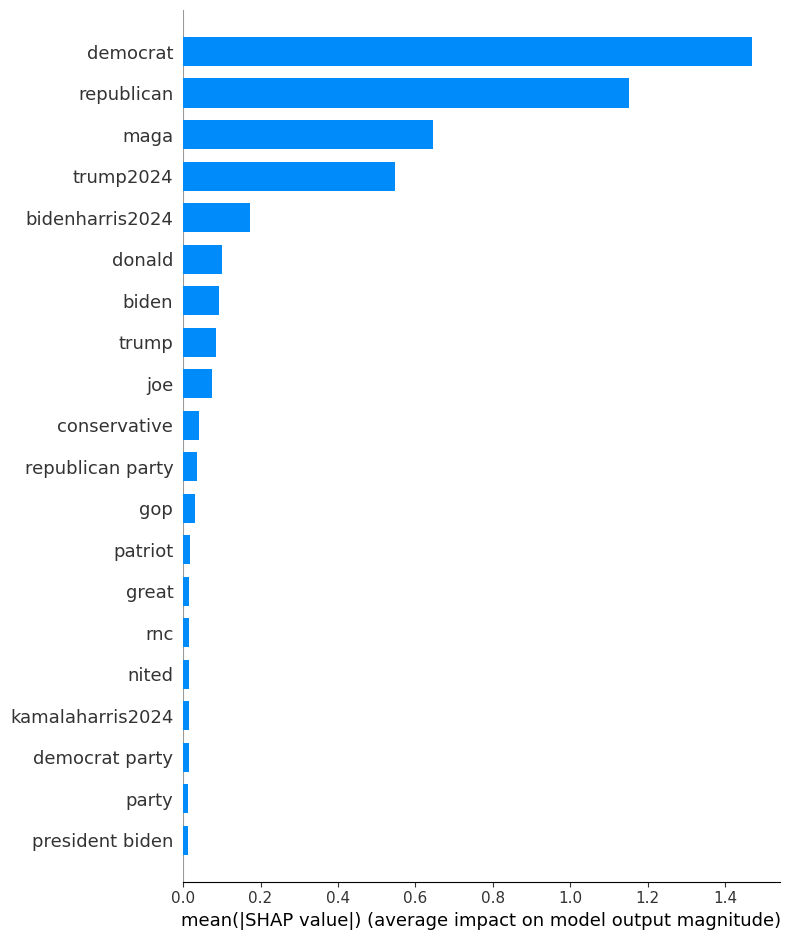

In [13]:
# Mean absolute SHAP values per feature
mean_abs_shap = np.abs(shap_dense).mean(axis=0)

# Top 50 features
top_idx = np.argsort(mean_abs_shap)[-50:]
feature_names_top = feature_names[top_idx]
shap_top = shap_dense[:, top_idx]
X_top = X_dense[:, top_idx]

# Global feature importance bar plot
shap.summary_plot(shap_top, features=X_top, feature_names=feature_names_top, plot_type="bar")


In [14]:
# Check class encoding
print("Class labels:", lgb_model.classes_)
print("Positive class (index 1):", lgb_model.classes_[1])
print("Negative class (index 0):", lgb_model.classes_[0])


Class labels: ['democrat' 'republican']
Positive class (index 1): republican
Negative class (index 0): democrat


In [15]:
feature_importance = []

for i, feature_name in enumerate(feature_names):
    feature_vals = X_dense[:, i]
    shap_vals = shap_dense[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Active SHAP': mean_shap_when_present,
            'Active Occurences': mask.sum(),
            'Direction': 'republican' if mean_shap_when_present > 0 else 'democrat'
        })

df = pd.DataFrame(feature_importance).sort_values(
    by='Active SHAP', 
    ascending=False
)


In [16]:
print("Directional Importance (top 10 pushing toward REPUBLICAN):")
df.head(10)

Directional Importance (top 10 pushing toward REPUBLICAN):


,Feature,Active SHAP,Active Occurences,Direction
13528,republican,2.559829,1589,republican
10086,magacultmorons,2.089745,9,republican
16970,trump2024,2.060670,877,republican
9919,maga,1.557307,5791,republican
5619,every democrat,1.557072,11,republican
4314,democrat administration,1.534791,1,republican
13710,republicanism,1.521981,2,republican
10085,magacult,1.476824,8,republican
4482,democrat party,1.462470,112,republican
17008,trump2024istheonlychoice,1.370396,3,republican


In [17]:
print("Directional Importance (top 10 pushing toward DEMOCRAT):")
df.tail(10)

Directional Importance (top 10 pushing toward DEMOCRAT):


,Feature,Active SHAP,Active Occurences,Direction
4624,democratscheat,-1.782479,2,democrat
15997,thedemocrats,-1.857882,4,democrat
2221,bidenharris2024toprotectdemocracy,-1.951995,4,democrat
4622,democratsareevil,-2.019919,2,democrat
4625,democratsdividinganddestroyingamerica,-2.122125,2,democrat
4621,democratsaredestroyingamerica,-2.802426,3,democrat
4626,democratshateamerica,-2.990845,5,democrat
4308,democrat,-3.644132,1904,democrat
8786,kamalaharris2024,-4.677064,8,democrat
2219,bidenharris2024,-5.483779,114,democrat


In [18]:
print(type(X_dense))
print(X_dense.shape)
print(f"Array size: {X_dense.nbytes / 1e9:.2f} GB")

print(type(shap_dense))
print(shap_dense.shape)


<class 'numpy.ndarray'>
(50000, 20000)
Array size: 8.00 GB
<class 'numpy.ndarray'>
(50000, 20000)


In [19]:
mean_abs_shap = np.abs(shap_dense).mean(axis=0)
non_zero_mask = mean_abs_shap > 0
non_zero_indices = np.where(non_zero_mask)[0]
top_features_idx = non_zero_indices[np.argsort(mean_abs_shap[non_zero_indices])[::-1]]

results = []
for feat_idx in top_features_idx:
    feature_vals = X_dense[:, feat_idx]
    feature_shaps = shap_dense[:, feat_idx]
    
    baseline_mask = feature_vals == 0
    active_mask = feature_vals > 0
    
    baseline_shap = feature_shaps[baseline_mask].mean() if baseline_mask.sum() > 0 else 0
    active_shap = feature_shaps[active_mask].mean() if active_mask.sum() > 0 else 0
    
    results.append({
        'Feature': feature_names[feat_idx],
        'Total_Occurrences': len(feature_vals),
        'Active_Occurrences': active_mask.sum(),
        'Density': round(active_mask.sum() / len(feature_vals), 3),
        'Sparsity': round(1 - active_mask.sum() / len(feature_vals), 3),
        'Mean_Abs_SHAP': round(mean_abs_shap[feat_idx], 4),
        'Mean_Raw_SHAP': round(feature_shaps.mean(), 4),
        'Baseline_SHAP': round(baseline_shap, 4),
        'Active_SHAP': round(active_shap, 4),
        'Active_Minus_Baseline': round(active_shap - baseline_shap, 4),
        'Std_SHAP': round(feature_shaps.std(), 4),
        'Max_SHAP': round(feature_shaps.max(), 4),
        'Min_SHAP': round(feature_shaps.min(), 4),
    })

party_shap = pd.DataFrame(results)

In [20]:
party_shap = party_shap.sort_values(
    by='Mean_Abs_SHAP', 
    ascending=False)
party_shap.head(20)

,Feature,Total_Occurrences,Active_Occurrences,Density,Sparsity,Mean_Abs_SHAP,Mean_Raw_SHAP,Baseline_SHAP,Active_SHAP,Active_Minus_Baseline,Std_SHAP,Max_SHAP,Min_SHAP
0,democrat,50000,1904,0.038,0.962,1.4682,1.1907,1.3821,-3.6441,-5.0262,0.9682,1.9248,-4.7404
1,republican,50000,1589,0.032,0.968,1.1524,-0.9897,-1.1062,2.5598,3.6660,0.6705,3.3974,-1.6474
2,maga,50000,5791,0.116,0.884,0.6466,-0.2859,-0.5273,1.5573,2.0846,0.6801,1.9222,-0.7146
3,trump2024,50000,877,0.018,0.982,0.5477,-0.4754,-0.5207,2.0607,2.5814,0.3658,2.5865,-0.7715
4,bidenharris2024,50000,114,0.002,0.998,0.1719,0.1469,0.1597,-5.4838,-5.6435,0.2718,0.2629,-6.2725
5,donald,50000,4294,0.086,0.914,0.1017,-0.0129,-0.0627,0.5168,0.5795,0.1672,0.8768,-0.1241
6,biden,50000,21292,0.426,0.574,0.0926,-0.0267,0.0563,-0.1387,-0.1950,0.1107,0.2989,-0.7562
7,trump,50000,11881,0.238,0.762,0.0856,-0.0077,-0.0608,0.1628,0.2237,0.1046,0.4501,-0.2322
8,joe,50000,3822,0.076,0.924,0.0758,-0.0031,0.0394,-0.5156,-0.5549,0.1527,0.1335,-1.0761
9,conservative,50000,2391,0.048,0.952,0.0419,0.0132,-0.0150,0.5762,0.5913,0.1297,0.7315,-0.3016


In [21]:
shap_raw_dense = shap_dense 
abs_shap_dense = np.abs(shap_dense)
max_shap_per_instance = np.abs(shap_dense).max(axis=1)
high_leverage_mask = max_shap_per_instance > 2.0
dominant_feature_indices = np.argmax(abs_shap_dense, axis=1)
high_leverage_indices = dominant_feature_indices[high_leverage_mask]
unique_indices, counts = np.unique(high_leverage_indices, return_counts=True)
distinct_high_leverage_terms = feature_names[unique_indices]

mean_raw_direction = []
peak_shap_values = []  
lowest_shap_values = []  
range_shap_values = []
prediction_mode = []

for j in unique_indices:
    instance_mask = high_leverage_mask & (dominant_feature_indices == j)
    
    # Calculate SHAP statistics
    mean_raw = np.mean(shap_raw_dense[instance_mask, j])
    mean_raw_direction.append(mean_raw)
    
    max_shap = np.max(shap_raw_dense[instance_mask, j])
    min_shap = np.min(shap_raw_dense[instance_mask, j])
    
    # Peak = value with highest absolute magnitude (most extreme)
    if abs(min_shap) > abs(max_shap):
        peak_shap = min_shap
        lowest_shap = max_shap 
    else:
        peak_shap = max_shap
        lowest_shap = min_shap 
    
    peak_shap_values.append(peak_shap)
    lowest_shap_values.append(lowest_shap)
    
    # Range
    range_shap = max_shap - min_shap
    range_shap_values.append(range_shap)
    
    predictions_for_feature = y_sample_test[instance_mask]
    most_common_pred = pd.Series(predictions_for_feature).mode()[0]
    prediction_mode.append(most_common_pred)
    
high_leverage_df = pd.DataFrame({
    'Feature': distinct_high_leverage_terms,
    'Count': counts,
    'Mean_When_Dominant': mean_raw_direction,
    'Peak_When_Dominant': peak_shap_values,
    'Lowest_When_Dominant': lowest_shap_values,
    'Range_When_Dominant': range_shap_values,
    'Predicted_Class': prediction_mode
})

high_leverage_df = high_leverage_df.sort_values(by=['Count'], ascending=False)
high_leverage_df

,Feature,Count,Mean_When_Dominant,Peak_When_Dominant,Lowest_When_Dominant,Range_When_Dominant,Predicted_Class
2,democrat,1889,-3.652993,-4.740393,-2.216869,2.523524,democrat
10,republican,1106,2.707976,3.397424,2.000531,1.396893,republican
11,trump2024,609,2.286338,2.586532,2.000097,0.586435,republican
0,bidenharris2024,114,-5.483779,-6.272505,-3.114328,3.158177,democrat
6,kamalaharris2024,8,-4.677064,-6.046587,-3.932628,2.113959,democrat
9,magacultmorons,5,2.516431,2.516672,2.516171,0.000501,republican
5,democratshateamerica,4,-3.256031,-3.875063,-2.686943,1.188120,democrat
1,bidenharris2024toprotectdemocracy,2,-2.358055,-2.549722,-2.166387,0.383335,democrat
3,democratsaredestroyingamerica,2,-3.004720,-3.710044,-2.299396,1.410647,democrat
4,democratsdividinganddestroyingamerica,2,-2.122125,-2.146727,-2.097523,0.049204,democrat


In [22]:
print(sum(high_leverage_df['Count']))
print((high_leverage_df['Feature']).nunique())

3743
12


## Democrat Sentiment Classifier

50000
26455060
0.18899976034830387


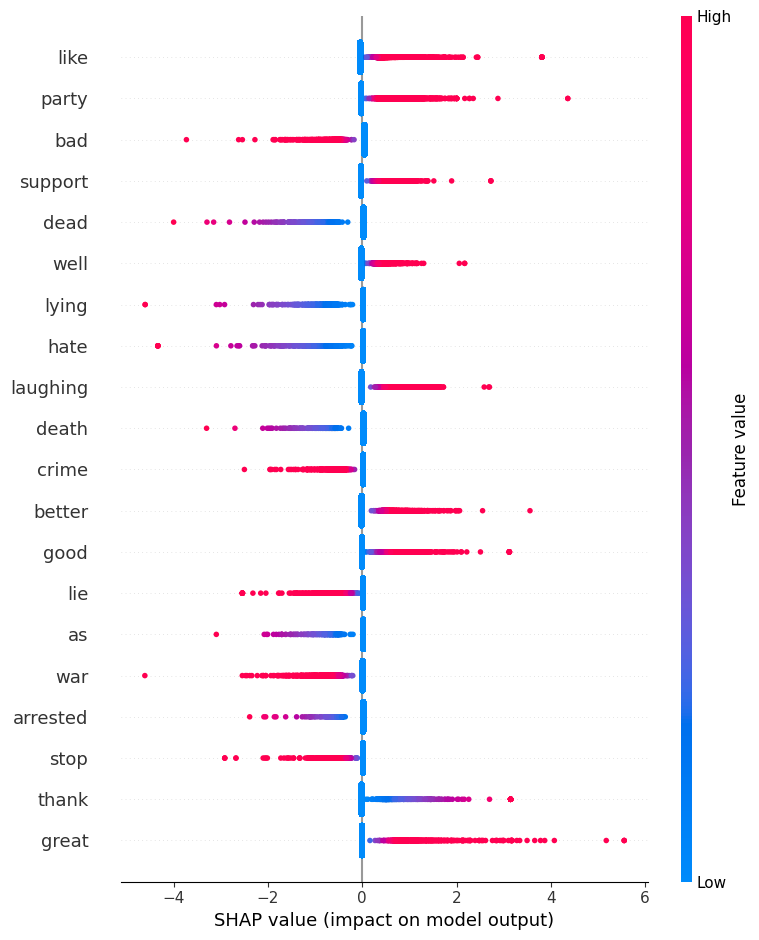

In [23]:
model = joblib.load("models/LinearSVC_democrat_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

democrat_train = train[train['party'] == 'democrat'].copy()
democrat_predict = predictions[predictions['party'] == 'democrat'].copy()

X_train, y_train = democrat_train['clean_text'], democrat_train['sentiment']
X_test, y_test = democrat_predict['clean_text'], democrat_predict['sentiment']

SAMPLE_SIZE = min(50000, len(X_test)/100)
print(SAMPLE_SIZE)
TOTAL_RECORDS = len(X_test)
print(TOTAL_RECORDS)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS
print(test_ratio * 100)

if test_ratio < 1.0:
    _, sample_indices, _, _ = train_test_split(
        y_test.index,
        y_test,
        test_size=test_ratio,
        stratify=y_test,
        random_state=42
    )

    X_sample_test = X_test.loc[sample_indices]
    y_sample_test = y_test.loc[sample_indices]
else:
    X_sample_test = X_test
    y_sample_test = y_test

democrat_tfidf = tfidf.transform(X_sample_test)
democrat_tfidf_dense = democrat_tfidf.toarray()

explainer = shap.LinearExplainer(clf, democrat_tfidf_dense)
shap_values = explainer.shap_values(democrat_tfidf_dense)

dem_feature_names = tfidf.get_feature_names_out()

shap.summary_plot(
    shap_values, 
    democrat_tfidf_dense, 
    feature_names=dem_feature_names,
    title="SHAP Summary: Democratic Sentiment Classification"
)

In [24]:
class_labels = clf.classes_
print(class_labels)

['negative' 'positive']


In [25]:
type(shap_values)
shap_dense = shap_values

In [26]:
print(type(democrat_tfidf_dense))
print(democrat_tfidf_dense.shape)
print(f"Array size: {democrat_tfidf_dense.nbytes / 1e9:.2f} GB")

print(type(shap_dense))
print(shap_dense.shape)


<class 'numpy.ndarray'>
(50000, 10000)
Array size: 4.00 GB
<class 'numpy.ndarray'>
(50000, 10000)


In [27]:
feature_importance = []

for i, feature_name in enumerate(dem_feature_names):
    feature_vals = democrat_tfidf_dense[:, i]
    shap_vals = shap_dense[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Active_SHAP': mean_shap_when_present,
            'Count_Present': mask.sum(),
            'Direction': 'positive' if mean_shap_when_present > 0 else 'negative'
        })

dem_df = pd.DataFrame(feature_importance).sort_values(
    by='Active_SHAP', 
    ascending=False
)


In [28]:
print("Directional Importance (top 10 pushing toward negative sentiment):")
dem_df.head(10)

Directional Importance (top 10 pushing toward negative sentiment):


,Feature,Active_SHAP,Count_Present,Direction
740,awesome,1.626253,70,positive
5283,lmao,1.415958,112,positive
5354,love,1.364953,559,positive
1931,congratulation,1.304814,31,positive
5285,lmfao,1.228882,32,positive
4098,hahaha,1.225003,32,positive
393,amazing,1.216857,117,positive
895,best,1.214894,511,positive
4035,greatest,1.213550,61,positive
4017,great,1.180623,592,positive


In [29]:
print("Directional Importance (top 10 pushing toward negative sentiment):")
dem_df.tail(10)

Directional Importance (top 10 pushing toward negative sentiment):


,Feature,Active_SHAP,Count_Present,Direction
4477,humiliation,-1.146744,10,negative
9575,worst,-1.157739,317,negative
2898,doomed,-1.158570,15,negative
3248,evil,-1.190754,307,negative
3723,fucked,-1.229075,64,negative
4262,hated,-1.246660,44,negative
9639,wtf,-1.291687,116,negative
6496,pissed,-1.334221,60,negative
1524,ca win,-1.345024,28,negative
4324,hell,-1.676837,332,negative


In [30]:
max_abs_shap = np.abs(shap_dense).max(axis=1) 

df_pred = pd.DataFrame({
    'predicted_party': y_sample_test.values,
    'max_abs_shap': max_abs_shap
})

pos_pred = df_pred[df_pred.predicted_party == 'positive']
neg_pred = df_pred[df_pred.predicted_party == 'negative']

print("Democrat predictions SHAP stats:")
pos_pred['max_abs_shap'].describe()


Democrat predictions SHAP stats:


count    21892.000000
mean         0.762868
std          0.518995
min          0.046631
25%          0.439971
50%          0.659066
75%          0.962135
max          5.876346
Name: max_abs_shap, dtype: float64

In [31]:
neg_pred['max_abs_shap'].describe()

count    28108.000000
mean         0.660887
std          0.524215
min          0.046631
25%          0.251038
50%          0.591760
75%          0.882819
max          6.632280
Name: max_abs_shap, dtype: float64

In [32]:
print(np.shape(shap_values))


(50000, 10000)


In [33]:
mean_abs_shap = np.abs(shap_dense).mean(axis=0)
non_zero_mask = mean_abs_shap > 0
non_zero_indices = np.where(non_zero_mask)[0]
top_features_idx = non_zero_indices[np.argsort(mean_abs_shap[non_zero_indices])[::-1]]

results = []
for feat_idx in top_features_idx:
    feature_vals = democrat_tfidf_dense[:, feat_idx]
    feature_shaps = shap_dense[:, feat_idx]
    
    baseline_mask = feature_vals == 0
    active_mask = feature_vals > 0
    
    baseline_shap = feature_shaps[baseline_mask].mean() if baseline_mask.sum() > 0 else 0
    active_shap = feature_shaps[active_mask].mean() if active_mask.sum() > 0 else 0
    
    results.append({
        'Feature': dem_feature_names[feat_idx],
        'Active_Occurrences': active_mask.sum(),
        'Density': round((active_mask.sum() / len(feature_vals)), 3) * 100,
        'Sparsity': round(1 - active_mask.sum() / len(feature_vals), 3) * 100,
        'Baseline_SHAP': round(baseline_shap, 4),
        'Active_SHAP': round(active_shap, 4),
        'Active_Minus_Baseline': round(active_shap - baseline_shap, 4),
        'Mean_Raw_SHAP': round(feature_shaps.mean(), 4),
        'Mean_Abs_SHAP': round(mean_abs_shap[feat_idx], 4),
        'Std_SHAP': round(feature_shaps.std(), 4),
         # max and min include non-active occurences         
        'Max_SHAP': round(feature_shaps.max(), 4), 
        'Min_SHAP': round(feature_shaps.min(), 4),
    })

dem_shap = pd.DataFrame(results)
dem_shap = dem_shap.sort_values(by=['Mean_Abs_SHAP'], ascending=False)
dem_shap.head(10)

,Feature,Active_Occurrences,Density,Sparsity,Baseline_SHAP,Active_SHAP,Active_Minus_Baseline,Mean_Raw_SHAP,Mean_Abs_SHAP,Std_SHAP,Max_SHAP,Min_SHAP
0,like,3606,7.2,92.8,-0.0426,0.5697,0.6123,0.0015,0.0807,0.1811,3.8101,-0.0426
1,party,2542,5.1,94.9,-0.0220,0.6825,0.7046,0.0138,0.0556,0.1712,4.3589,-0.0220
2,bad,645,1.3,98.7,0.0466,-0.7226,-0.7692,0.0367,0.0554,0.0952,0.0466,-3.7298
3,support,965,1.9,98.1,-0.0305,0.4910,0.5214,-0.0204,0.0393,0.0799,2.7276,-0.0305
4,dead,261,0.5,99.5,0.0259,-0.9836,-1.0095,0.0206,0.0309,0.0806,0.0259,-4.0009
5,well,969,1.9,98.1,-0.0209,0.4461,0.4670,-0.0118,0.0291,0.0705,2.1715,-0.0209
6,lying,469,0.9,99.1,0.0199,-0.9056,-0.9255,0.0112,0.0282,0.0996,0.0199,-4.6048
7,hate,482,1.0,99.0,0.0195,-0.9022,-0.9218,0.0106,0.0280,0.1075,0.0195,-4.3359
8,laughing,597,1.2,98.8,-0.0159,0.9830,0.9988,-0.0039,0.0274,0.1171,2.6975,-0.0159
9,death,265,0.5,99.5,0.0225,-0.8810,-0.9035,0.0177,0.0271,0.0711,0.0225,-3.3025


In [34]:
shap_raw_dense = shap_dense 
abs_shap_dense = np.abs(shap_dense)
max_shap_per_instance = np.abs(shap_dense).max(axis=1)
high_leverage_mask = max_shap_per_instance > 2.0
dominant_feature_indices = np.argmax(abs_shap_dense, axis=1)
high_leverage_indices = dominant_feature_indices[high_leverage_mask]
unique_indices, counts = np.unique(high_leverage_indices, return_counts=True)
distinct_high_leverage_terms = dem_feature_names[unique_indices]

mean_raw_direction = []
peak_shap_values = []  
lowest_shap_values = []  
range_shap_values = []
prediction_mode = []

for j in unique_indices:
    instance_mask = high_leverage_mask & (dominant_feature_indices == j)
    
    # Calculate SHAP statistics
    mean_raw = np.mean(shap_raw_dense[instance_mask, j])
    mean_raw_direction.append(mean_raw)
    
    max_shap = np.max(shap_raw_dense[instance_mask, j])
    min_shap = np.min(shap_raw_dense[instance_mask, j])
    
    # Peak = value with highest absolute magnitude (most extreme)
    peak_shap = max_shap if abs(max_shap) > abs(min_shap) else min_shap
    # Least extreme (closest to 0)
    lowest_shap = min_shap if abs(max_shap) > abs(min_shap) else max_shap
    
    peak_shap_values.append(peak_shap)
    lowest_shap_values.append(lowest_shap)
    
    # Range
    range_shap = max_shap - min_shap
    range_shap_values.append(range_shap)
    
    predictions_for_feature = y_sample_test[instance_mask]
    most_common_pred = pd.Series(predictions_for_feature).mode()[0]
    prediction_mode.append(most_common_pred)
    
high_leverage_df = pd.DataFrame({
    'Feature': distinct_high_leverage_terms,
    'Count': counts,
    'Mean_When_Dominant': mean_raw_direction,
    'Peak_When_Dominant': peak_shap_values,
    'Lowest_When_Dominant': lowest_shap_values,
    'Range_When_Dominant': range_shap_values,
    'Predicted_Class': prediction_mode
})

high_leverage_df = high_leverage_df.sort_values(by=['Count'], ascending=False)
high_leverage_df.head(10)

,Feature,Count,Mean_When_Dominant,Peak_When_Dominant,Lowest_When_Dominant,Range_When_Dominant,Predicted_Class
105,love,72,3.103168,5.876346,2.011753,3.864593,positive
79,hell,71,-3.343686,-6.632280,-2.014588,4.617693,negative
70,great,52,2.855622,5.555832,2.011955,3.543876,positive
13,best,46,2.511921,4.129338,2.003445,2.125893,positive
102,lol,45,2.656571,3.424421,2.008819,1.415602,positive
78,heart,36,2.309699,4.688007,2.004018,2.683989,positive
178,yes,35,2.620151,3.103662,2.014996,1.088666,positive
50,evil,31,-2.619487,-5.298367,-2.004678,3.293689,negative
153,thank,31,2.998131,3.146543,2.016062,1.130481,positive
64,fuck,26,-2.491104,-3.984384,-2.009991,1.974392,negative


In [35]:
print(sum(high_leverage_df['Count']))
print((high_leverage_df['Feature']).nunique())

frequent_features = high_leverage_df[high_leverage_df['Count'] >= 5]
num_frequent_features = frequent_features['Feature'].nunique()
total_frequent_instances = frequent_features['Count'].sum()

print(num_frequent_features)       
print(total_frequent_instances)   

1209
179
61
979


In [36]:
print(high_leverage_df['Predicted_Class'].unique())

['positive' 'negative']


In [37]:
pos_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'positive') & 
                                 (high_leverage_df['Count'] >= 5)]
num_pos_featurs = pos_features['Feature'].nunique()
total_pos_features = pos_features['Count'].sum()

print(num_pos_featurs)       
print(total_pos_features)   

24
525


In [38]:
pos_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'positive')]
num_pos_featurs = pos_features['Feature'].nunique()
total_pos_features = pos_features['Count'].sum()

print(num_pos_featurs)       
print(total_pos_features)   

64
610


In [39]:
neg_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'negative') & 
                                 (high_leverage_df['Count'] >= 5)]
num_neg_featurs = neg_features['Feature'].nunique()
total_neg_features = neg_features['Count'].sum()

print(num_neg_featurs)       
print(total_neg_features)

37
454


In [40]:
neg_features = high_leverage_df[(high_leverage_df['Predicted_Class'] == 'negative')]
num_neg_featurs = neg_features['Feature'].nunique()
total_neg_features = neg_features['Count'].sum()

print(num_neg_featurs)       
print(total_neg_features)

115
599


## Republican Sentiment Classifier

50000
9574156
0.005222392449005427


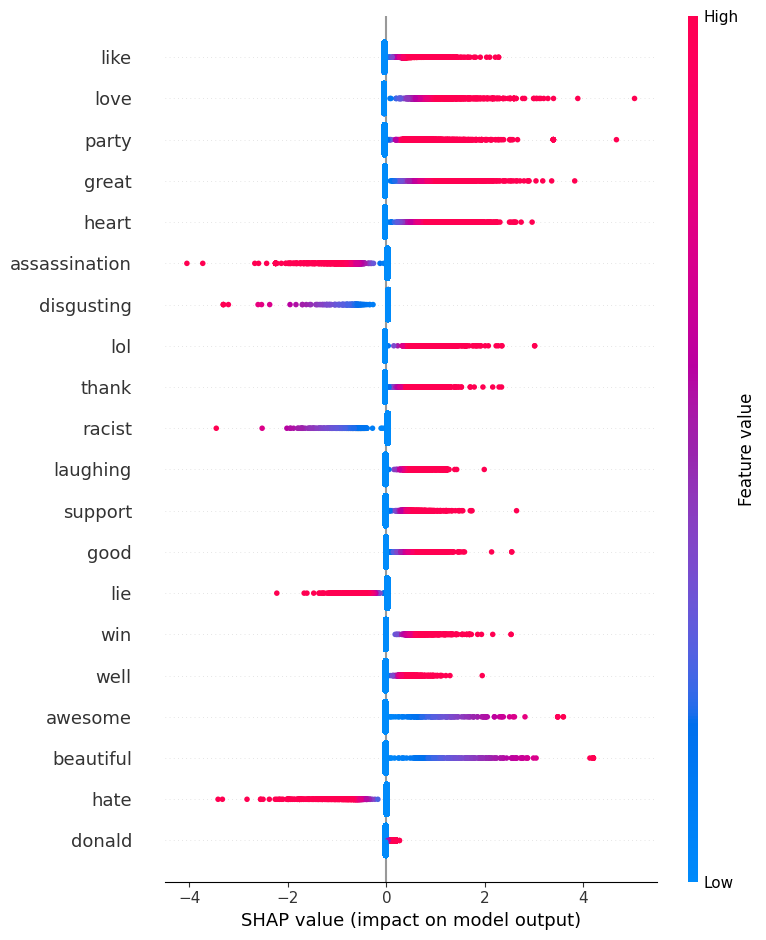

In [41]:
model = joblib.load("models/LinearSVC_republican_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']
clf = model.named_steps['clf']

rep_train = train[train['party'] == 'republican'].copy()
rep_predict = predictions[predictions['party'] == 'republican'].copy()

X_train, y_train = rep_train['clean_text'], rep_train['sentiment']
X_test, y_test = rep_predict['clean_text'], rep_predict['sentiment']

SAMPLE_SIZE = min(50000, len(X_test)/100)
print(SAMPLE_SIZE)
TOTAL_RECORDS = len(X_test)
print(TOTAL_RECORDS)
test_ratio = SAMPLE_SIZE / TOTAL_RECORDS
print(test_ratio)

if test_ratio < 1.0:
    _, sample_indices, _, _ = train_test_split(
        y_test.index,
        y_test,
        test_size=test_ratio,
        stratify=y_test,
        random_state=42
    )

    X_sample_test = X_test.loc[sample_indices]
    y_sample_test = y_test.loc[sample_indices]
else:
    X_sample_test = X_test
    y_sample_test = y_test

republican_tfidf = tfidf.transform(X_sample_test)
republican_tfidf_dense = republican_tfidf.toarray()

explainer = shap.LinearExplainer(clf, republican_tfidf_dense)
shap_values = explainer.shap_values(republican_tfidf_dense)

rep_feature_names = tfidf.get_feature_names_out()

shap.summary_plot(
    shap_values, 
    republican_tfidf_dense,
    feature_names=rep_feature_names,
    title="SHAP Summary: Republican Sentiment Classification"
)

In [42]:
feature_importance = []

for i, feature_name in enumerate(rep_feature_names):
    feature_vals = republican_tfidf_dense[:, i]
    shap_vals = shap_values[:, i]
    
    # Only consider samples where feature is present
    mask = feature_vals > 0
    if mask.sum() > 0:
        mean_shap_when_present = shap_vals[mask].mean()
        feature_importance.append({
            'Feature': feature_name,
            'Active_SHAP': mean_shap_when_present,
            'Count_Present': mask.sum(),
            'Direction': 'positive' if mean_shap_when_present > 0 else 'negative'
        })

rep_df = pd.DataFrame(feature_importance).sort_values(
    by='Active_SHAP', 
    ascending=False
)

print("Directional Importance (top 10 pushing toward positive sentiment):")
rep_df.head(10)


Directional Importance (top 10 pushing toward positive sentiment):


,Feature,Active_SHAP,Count_Present,Direction
734,bad as,1.797786,4,positive
805,beautiful,1.509259,229,positive
695,awesome,1.255054,128,positive
861,best,1.178480,482,positive
341,amazing,1.105605,171,positive
3592,hahaha,1.102807,32,positive
9587,wow,1.100726,217,positive
9457,winner,1.082070,49,positive
5783,outstanding,1.053212,16,positive
3523,greatest,1.047487,115,positive


In [43]:
print("Directional Importance (top 10 pushing toward negative sentiment):")
rep_df.tail(10)

Directional Importance (top 10 pushing toward negative sentiment):


,Feature,Active_SHAP,Count_Present,Direction
6609,rapist,-1.079360,323,negative
7324,scumbag,-1.085238,23,negative
3166,fuck,-1.090082,344,negative
7588,slavery,-1.115694,23,negative
7518,sick,-1.168635,185,negative
1295,ca win,-1.226302,14,negative
2249,disgrace,-1.230302,62,negative
1329,cancer,-1.255206,56,negative
9605,wtf,-1.282041,81,negative
3801,hell,-1.383791,269,negative


In [44]:
rep_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9673 entries, 734 to 3801
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Feature        9673 non-null   object 
 1   Active_SHAP    9673 non-null   float64
 2   Count_Present  9673 non-null   int64  
 3   Direction      9673 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 377.9+ KB


In [45]:
shap_dense = shap_values

In [46]:
# feature_to_idx = {name: i for i, name in enumerate(feature_names)}

# top_features = rep_df.head(3)['Feature'].tolist()
# refined_stats = []

# print(f"Analyzing {len(top_features)} features against {len(rep_predict):,} rows...")

# for feature in top_features:
#     # Find rows containing the feature
#     full_mask = rep_predict['clean_text'].str.contains(fr'\b{feature}\b', regex=True, na=False)
#     matches = rep_predict[full_mask].copy()
#     count = len(matches)
    
#     if count == 0:
#         print(f"No matches for '{feature}' — skipped")
#         continue

#     # Transform subset text
#     target_tfidf = tfidf.transform(matches['clean_text'])
#     target_tfidf_dense = target_tfidf.toarray()
    
#     # Compute SHAP values on subset
#     target_shaps = explainer.shap_values(target_tfidf_dense)
#     if isinstance(target_shaps, list):
#         target_shaps = target_shaps[-1]  # positive sentiment class

#     f_idx = feature_to_idx[feature]
#     true_shaps_for_feature = target_shaps[:, f_idx]

#     # Compute baseline SHAP: mean SHAP when the feature is absent in the full dataset
#     baseline_mask = ~full_mask
#     if baseline_mask.sum() > 0:
#         baseline_tfidf = tfidf.transform(rep_predict.loc[baseline_mask, 'clean_text']).toarray()
#         baseline_shaps = explainer.shap_values(baseline_tfidf)
#         if isinstance(baseline_shaps, list):
#             baseline_shaps = baseline_shaps[-1]
#         baseline_shap = baseline_shaps[:, f_idx].mean()
#     else:
#         baseline_shap = 0

#     # True baseline-adjusted SHAP
#     true_mean_shap = true_shaps_for_feature.mean() - baseline_shap

#     # Empirical positive rate
#     pos_pct = (matches['sentiment'] == 'positive').mean() * 100

#     refined_stats.append({
#         'Feature': feature,
#         'True_Mean_SHAP': round(true_mean_shap, 4),
#         'Full_Count': count,
#         'Actual_Positive_%': f"{pos_pct:.1f}%",
#         'Sample_SHAP_Diff': round(true_mean_shap - rep_df.loc[rep_df['Feature']==feature, 'Active_SHAP'].values[0], 4)
#     })

#     print(f"Done: {feature} | True SHAP: {true_mean_shap:.4f}")

# table = pd.DataFrame(refined_stats)
# table


In [47]:
max_abs_shap = np.abs(shap_dense).max(axis=1) 

df_pred = pd.DataFrame({
    'predicted_party': y_sample_test.values,
    'max_abs_shap': max_abs_shap
})

pos_pred = df_pred[df_pred.predicted_party == 'positive']
neg_pred = df_pred[df_pred.predicted_party == 'negative']

print("Republican predictions SHAP stats:")
pos_pred['max_abs_shap'].describe()


Republican predictions SHAP stats:


count    26308.000000
mean         0.690405
std          0.454293
min          0.047558
25%          0.392059
50%          0.622064
75%          0.890455
max          5.201424
Name: max_abs_shap, dtype: float64

In [48]:
neg_pred['max_abs_shap'].describe()

count    23692.000000
mean         0.678058
std          0.467762
min          0.047558
25%          0.305835
50%          0.632097
75%          0.908559
max          5.105797
Name: max_abs_shap, dtype: float64

In [49]:
mean_abs_shap = np.abs(shap_dense).mean(axis=0)
non_zero_mask = mean_abs_shap > 0
non_zero_indices = np.where(non_zero_mask)[0]
top_features_idx = non_zero_indices[np.argsort(mean_abs_shap[non_zero_indices])[::-1]]

results = []
for feat_idx in top_features_idx:
    feature_vals = republican_tfidf_dense[:, feat_idx]
    feature_shaps = shap_dense[:, feat_idx]
    
    baseline_mask = feature_vals == 0
    active_mask = feature_vals > 0
    
    baseline_shap = feature_shaps[baseline_mask].mean() if baseline_mask.sum() > 0 else 0
    active_shap = feature_shaps[active_mask].mean() if active_mask.sum() > 0 else 0
    
    results.append({
        'Feature': rep_feature_names[feat_idx],
        'Active_Occurrences': active_mask.sum(),
        'Density': round((active_mask.sum() / len(feature_vals)), 3) * 100,
        'Sparsity': round(1 - active_mask.sum() / len(feature_vals), 3) * 100,
        'Baseline_SHAP': round(baseline_shap, 4),
        'Active_SHAP': round(active_shap, 4),
        'Active_Minus_Baseline': round(active_shap - baseline_shap, 4),
        'Mean_Abs_SHAP': round(mean_abs_shap[feat_idx], 4),
        'Mean_Raw_SHAP': round(feature_shaps.mean(), 4),
        'Std_SHAP': round(feature_shaps.std(), 4),
         # max and min include non-active occurences         
        'Max_SHAP': round(feature_shaps.max(), 4), 
        'Min_SHAP': round(feature_shaps.min(), 4),
    })

rep_shap = pd.DataFrame(results)
rep_shap = rep_shap.sort_values(by=['Mean_Abs_SHAP'], ascending=False)
rep_shap.head(10)

,Feature,Active_Occurrences,Density,Sparsity,Baseline_SHAP,Active_SHAP,Active_Minus_Baseline,Mean_Abs_SHAP,Mean_Raw_SHAP,Std_SHAP,Max_SHAP,Min_SHAP
0,like,3746,7.5,92.5,-0.0390,0.5040,0.5431,0.0739,0.0017,0.1556,2.2773,-0.0390
1,love,1229,2.5,97.5,-0.0476,1.0414,1.0889,0.0720,-0.0208,0.1874,5.0370,-0.0476
2,party,2562,5.1,94.9,-0.0348,0.7266,0.7614,0.0702,0.0042,0.1918,4.6696,-0.0348
3,great,1138,2.3,97.7,-0.0313,0.9884,1.0198,0.0531,-0.0081,0.1665,3.8228,-0.0313
4,heart,1064,2.1,97.9,-0.0269,0.9122,0.9390,0.0457,-0.0069,0.1518,2.9576,-0.0269
5,assassination,1069,2.1,97.9,0.0201,-0.9319,-0.9520,0.0396,-0.0003,0.1498,0.0201,-4.0510
6,disgusting,172,0.3,99.7,0.0334,-0.8914,-0.9248,0.0364,0.0303,0.0622,0.0334,-3.3105
7,lol,527,1.1,98.9,-0.0264,0.8625,0.8890,0.0353,-0.0171,0.0987,3.0096,-0.0264
8,thank,600,1.2,98.8,-0.0267,0.6405,0.6672,0.0341,-0.0187,0.0806,2.3375,-0.0267
9,racist,410,0.8,99.2,0.0265,-0.7970,-0.8235,0.0328,0.0198,0.0813,0.0265,-3.4549


In [50]:
shap_raw_dense = shap_dense 
abs_shap_dense = np.abs(shap_dense)
max_shap_per_instance = np.abs(shap_dense).max(axis=1)
high_leverage_mask = max_shap_per_instance > 2.0
dominant_feature_indices = np.argmax(abs_shap_dense, axis=1)
high_leverage_indices = dominant_feature_indices[high_leverage_mask]
unique_indices, counts = np.unique(high_leverage_indices, return_counts=True)
distinct_high_leverage_terms = rep_feature_names[unique_indices]

mean_raw_direction = []
peak_shap_values = []  
lowest_shap_values = []  
range_shap_values = []
prediction_mode = []

for j in unique_indices:
    instance_mask = high_leverage_mask & (dominant_feature_indices == j)
    
    # Calculate SHAP statistics
    mean_raw = np.mean(shap_raw_dense[instance_mask, j])
    mean_raw_direction.append(mean_raw)
    
    max_shap = np.max(shap_raw_dense[instance_mask, j])
    min_shap = np.min(shap_raw_dense[instance_mask, j])
    
    # Peak = value with highest absolute magnitude (most extreme)
    if abs(min_shap) > abs(max_shap):
        peak_shap = min_shap
        lowest_shap = max_shap 
    else:
        peak_shap = max_shap
        lowest_shap = min_shap 
    
    peak_shap_values.append(peak_shap)
    lowest_shap_values.append(lowest_shap)
    
    # Range
    range_shap = max_shap - min_shap
    range_shap_values.append(range_shap)
    
    predictions_for_feature = y_sample_test[instance_mask]
    most_common_pred = pd.Series(predictions_for_feature).mode()[0]
    prediction_mode.append(most_common_pred)
    
high_leverage_df = pd.DataFrame({
    'Feature': distinct_high_leverage_terms,
    'Count': counts,
    'Mean_When_Dominant': mean_raw_direction,
    'Peak_When_Dominant': peak_shap_values,
    'Lowest_When_Dominant': lowest_shap_values,
    'Range_When_Dominant': range_shap_values,
    'Predicted_Class': prediction_mode
})

high_leverage_df = high_leverage_df.sort_values(by=['Count'], ascending=False)
high_leverage_df.head(10)

,Feature,Count,Mean_When_Dominant,Peak_When_Dominant,Lowest_When_Dominant,Range_When_Dominant,Predicted_Class
89,love,75,2.455189,5.037020,2.000573,3.036447,positive
8,beautiful,52,2.873683,4.199998,2.005856,2.194142,positive
64,great,38,2.451339,3.822785,2.008291,1.814493,positive
96,party,37,2.657401,4.669639,2.011858,2.657781,positive
74,hell,35,-2.641069,-5.105797,-2.012932,3.092865,negative
9,best,32,3.104613,5.201424,2.025938,3.175486,positive
73,heart,31,2.272662,2.957624,2.028748,0.928875,positive
3,assassination,23,-2.409881,-4.050998,-2.041278,2.009720,negative
4,awesome,21,2.639285,3.591787,2.016884,1.574903,positive
58,fuck,20,-2.624046,-3.835571,-2.049294,1.786276,negative


In [51]:
print(sum(high_leverage_df['Count']))
print((high_leverage_df['Feature']).nunique())

frequent_features = high_leverage_df[high_leverage_df['Count'] >= 5]
num_frequent_features = frequent_features['Feature'].nunique()
total_frequent_instances = frequent_features['Count'].sum()

print(num_frequent_features)       
print(total_frequent_instances)   

781
149
38
596


## Cross Party sentiment analysis

In [52]:
dem_shap.head()

,Feature,Active_Occurrences,Density,Sparsity,Baseline_SHAP,Active_SHAP,Active_Minus_Baseline,Mean_Raw_SHAP,Mean_Abs_SHAP,Std_SHAP,Max_SHAP,Min_SHAP
0,like,3606,7.2,92.8,-0.0426,0.5697,0.6123,0.0015,0.0807,0.1811,3.8101,-0.0426
1,party,2542,5.1,94.9,-0.0220,0.6825,0.7046,0.0138,0.0556,0.1712,4.3589,-0.0220
2,bad,645,1.3,98.7,0.0466,-0.7226,-0.7692,0.0367,0.0554,0.0952,0.0466,-3.7298
3,support,965,1.9,98.1,-0.0305,0.4910,0.5214,-0.0204,0.0393,0.0799,2.7276,-0.0305
4,dead,261,0.5,99.5,0.0259,-0.9836,-1.0095,0.0206,0.0309,0.0806,0.0259,-4.0009


In [53]:
rep_shap.head()

,Feature,Active_Occurrences,Density,Sparsity,Baseline_SHAP,Active_SHAP,Active_Minus_Baseline,Mean_Abs_SHAP,Mean_Raw_SHAP,Std_SHAP,Max_SHAP,Min_SHAP
0,like,3746,7.5,92.5,-0.0390,0.5040,0.5431,0.0739,0.0017,0.1556,2.2773,-0.0390
1,love,1229,2.5,97.5,-0.0476,1.0414,1.0889,0.0720,-0.0208,0.1874,5.0370,-0.0476
2,party,2562,5.1,94.9,-0.0348,0.7266,0.7614,0.0702,0.0042,0.1918,4.6696,-0.0348
3,great,1138,2.3,97.7,-0.0313,0.9884,1.0198,0.0531,-0.0081,0.1665,3.8228,-0.0313
4,heart,1064,2.1,97.9,-0.0269,0.9122,0.9390,0.0457,-0.0069,0.1518,2.9576,-0.0269


In [62]:
# Filter features by Active minus Baseline SHAP
dem_pos = dem_shap.copy()
rep_pos = rep_shap.copy()

# Separate positive and negative incremental features
dem_pos_features = dem_pos[dem_pos['Active_Minus_Baseline'] > 0].copy()
rep_pos_features = rep_pos[rep_pos['Active_Minus_Baseline'] > 0].copy()

dem_neg_features = dem_pos[dem_pos['Active_Minus_Baseline'] < 0].copy()
rep_neg_features = rep_pos[rep_pos['Active_Minus_Baseline'] < 0].copy()

def combine_features(dem_df, rep_df):
    """Combine Democrat and Republican SHAP features into a single table with categories."""
    dem_features = set(dem_df['Feature'])
    rep_features = set(rep_df['Feature'])
    
    universal_features = dem_features & rep_features
    dem_only_features = dem_features - rep_features
    rep_only_features = rep_features - dem_features
    
    overlap = len(universal_features) / max(len(dem_features), len(rep_features)) * 100
    print(f"Feature overlap: {overlap:.2f}%")
    
    all_features = list(universal_features) + list(dem_only_features) + list(rep_only_features)
    combined_data = []
    for feature in all_features:
        dem_row = dem_df[dem_df['Feature'] == feature]
        rep_row = rep_df[rep_df['Feature'] == feature]
        
        combined_data.append({
            'Feature': feature,
            'Category': ('Universal' if feature in universal_features 
                         else 'Democrat-specific' if feature in dem_only_features 
                         else 'Republican-specific'),
            'Dem_Active_SHAP': dem_row['Active_SHAP'].values[0] if not dem_row.empty else 0,
            'Rep_Active_SHAP': rep_row['Active_SHAP'].values[0] if not rep_row.empty else 0,
            'Dem_ActiveMinusBaseline': dem_row['Active_Minus_Baseline'].values[0] if not dem_row.empty else 0,
            'Rep_ActiveMinusBaseline': rep_row['Active_Minus_Baseline'].values[0] if not rep_row.empty else 0,
            'Dem_Count': dem_row['Active_Occurrences'].values[0] if not dem_row.empty else 0,
            'Rep_Count': rep_row['Active_Occurrences'].values[0] if not rep_row.empty else 0,
            'Abs_Diff_ActiveMinusBaseline': round(abs(
                (dem_row['Active_Minus_Baseline'].values[0] if not dem_row.empty else 0) -
                (rep_row['Active_Minus_Baseline'].values[0] if not rep_row.empty else 0)
            ), 4)
        })
        
    combined_df = pd.DataFrame(combined_data).sort_values(
        by='Abs_Diff_ActiveMinusBaseline', ascending=False
    ).reset_index(drop=True)
    
    return combined_df

# Positive features
combined_pos = combine_features(dem_pos_features, rep_pos_features)

# Negative features
combined_neg = combine_features(dem_neg_features, rep_neg_features)

# Category counts
print("\nPositive Category Counts:")
print(combined_pos['Category'].value_counts())

print("\nNegative Category Counts:")
print(combined_neg['Category'].value_counts())


Feature overlap: 44.71%
Feature overlap: 45.89%

Positive Category Counts:
Category
Republican-specific    2670
Democrat-specific      2528
Universal              2159
Name: count, dtype: int64

Negative Category Counts:
Category
Democrat-specific      2707
Republican-specific    2523
Universal              2296
Name: count, dtype: int64


In [55]:
print("Top 20 Positive Features:")
combined_pos.head(20)


Top 20 Positive Features:


,Feature,Category,Dem_Active_SHAP,Rep_Active_SHAP,Dem_ActiveMinusBaseline,Rep_ActiveMinusBaseline,Dem_Count,Rep_Count,Abs_Diff_ActiveMinusBaseline
0,bad as,Republican-specific,0.0000,1.7978,0.0000,1.7978,0,4,1.7978
1,nothing lie,Democrat-specific,0.9704,0.0000,0.9704,0.0000,6,0,0.9704
2,delicious,Republican-specific,0.0000,0.8787,0.0000,0.8787,0,13,0.8787
3,supremacist,Democrat-specific,0.7801,0.0000,0.7801,0.0000,27,0,0.7801
4,war iran,Democrat-specific,0.7499,0.0000,0.7499,0.0000,6,0,0.7499
5,funniest,Republican-specific,0.0000,0.6692,0.0000,0.6692,0,16,0.6692
6,fearless,Republican-specific,0.0000,0.6660,0.0000,0.6660,0,7,0.6660
7,adore,Republican-specific,0.0000,0.6578,0.0000,0.6578,0,4,0.6578
8,beautiful,Universal,0.8681,1.5093,0.8681,1.5243,30,229,0.6562
9,love american,Democrat-specific,0.6522,0.0000,0.6522,0.0000,1,0,0.6522


In [56]:
print("Top 20 Positive Features:")
combined_neg.head(20)


Top 20 Positive Features:


,Feature,Category,Dem_Active_SHAP,Rep_Active_SHAP,Dem_ActiveMinusBaseline,Rep_ActiveMinusBaseline,Dem_Count,Rep_Count,Abs_Diff_ActiveMinusBaseline
0,humiliation,Democrat-specific,-1.1467,0.0000,-1.1467,0.0000,10,0,1.1467
1,nothing good,Democrat-specific,-1.0281,0.0000,-1.0281,0.0000,8,0,1.0281
2,crappy,Democrat-specific,-0.9817,0.0000,-0.9896,0.0000,12,0,0.9896
3,suicidal,Democrat-specific,-0.8412,0.0000,-0.8412,0.0000,4,0,0.8412
4,frustrated,Democrat-specific,-0.8181,0.0000,-0.8181,0.0000,15,0,0.8181
5,stab,Democrat-specific,-0.8065,0.0000,-0.8065,0.0000,11,0,0.8065
6,murdering baby,Democrat-specific,-0.7854,0.0000,-0.7854,0.0000,2,0,0.7854
7,pissing,Democrat-specific,-0.7675,0.0000,-0.7675,0.0000,8,0,0.7675
8,lousy,Democrat-specific,-0.7610,0.0000,-0.7610,0.0000,10,0,0.7610
9,small square,Democrat-specific,-0.7542,0.0000,-0.7542,0.0000,2,0,0.7542


In [61]:
universal_positive = set(dem_pos_features['Feature']) & set(rep_pos_features['Feature'])
universal_negative = set(dem_neg_features['Feature']) & set(rep_neg_features['Feature'])

overlap_pos = len(universal_positive) / max(len(dem_pos_features), len(rep_pos_features)) * 100
overlap_neg = len(universal_negative) / max(len(dem_neg_features), len(rep_neg_features)) * 100

print(f"Positive feature overlap: {overlap_pos:.2f}%")
print(f"Negative feature overlap: {overlap_neg:.2f}%")


Positive feature overlap: 44.71%
Negative feature overlap: 45.89%


why do terms such as 'supremacist' appear?

In [ ]:
model = joblib.load("models/LinearSVC_democrat_sentiment_classifier.joblib")
tfidf = model.named_steps['tfidf']

In [ ]:
def inspect_feature_usage(term, df, text_col='clean_text', n=20):
    mask = df[text_col].str.contains(rf'\b{term}\b', case=False, na=False)
    matches = df[mask]
    
    print(f"Found {len(matches):,} matches for '{term}'")
    
    if not matches.empty:
        for _, row in matches.sample(min(n, len(matches))).iterrows():
            print(f"{row['sentiment'].upper()}:\n{row[text_col]}\n")
            print(f"{row['text']} \n\n")
            
inspect_feature_usage("supremacist", democrat_predict)


In [ ]:
words = [
    "supremacist",
    "war iran",
]

# Align feature space with TF-IDF model
tfidf_feature_names = tfidf.get_feature_names_out()
feature_to_idx = {name: i for i, name in enumerate(tfidf_feature_names)}
refined_stats = []
print(f"Analyzing {len(words)} features against 9.5M rows...")

for feature in words:
    # Skip words not in the model vocabulary
    if feature not in feature_to_idx:
        print(f"'{feature}' not in TF-IDF vocabulary — skipped")
        continue
    # Presence mask (lexical conditioning)
    full_mask = democrat_predict['clean_text'].str.contains(
        fr'\b{feature}\b', regex=True, na=False
    )
    matches = democrat_predict[full_mask].copy()
    count = len(matches)
    if count == 0:
        print(f"No matches for '{feature}'")
        continue
        
    # Recompute SHAP where feature is present
    target_tfidf = tfidf.transform(matches['clean_text'])
    target_shaps = explainer.shap_values(target_tfidf)
    
    if isinstance(target_shaps, list):
        target_shaps = target_shaps[-1]  # positive sentiment class
        
    # Extract true conditional SHAP
    f_idx = feature_to_idx[feature]
    true_mean_shap = target_shaps[:, f_idx].mean()
    
    # Empirical label check
    pos_pct = (matches['sentiment'] == 'positive').mean() * 100
    refined_stats.append({
        'Feature': feature,
        'True_Mean_SHAP': round(true_mean_shap, 4),
        'Full_Count': count,
        'Actual_Positive_%': f"{pos_pct:.1f}%"
    })
    
    print(f"Done: {feature} | True SHAP: {true_mean_shap:.4f}")
    
table = pd.DataFrame(refined_stats)
print("\nConditional SHAP (Feature Present Only):")
table